# Capstone Project 5 - Generative AI Applications

## Transformer-Based Generation of Public-Sector Contract Language

This notebook implements and evaluates a small custom PyTorch causal Transformer trained on a frozen corpus of FAR Subpart 52.2 provisions and clauses. The purpose is to study generation behavior and responsible-use risks, not to produce legally valid contract language.

**Current notebook status:** Dataset acquisition, source-boundary correction, clause-level partitioning, character-vocabulary construction, and sequence preprocessing are complete. The next phases implement, train, and evaluate the causal Transformer and analyze its generated outputs and responsible-use risks.


## 1. Environment and Reproducibility

The workflow records package versions, random seeds, device information, and configuration values. A CUDA-capable Colab runtime is preferred, with automatic CPU fallback.

In [1]:
from pathlib import Path
import os
import subprocess

REPO_URL = "https://github.com/icmsol/capstone-project-5-generative-ai-applications.git"
REPO_DIR = Path("/content/capstone-project-5-generative-ai-applications")

if REPO_DIR.exists():
    print("Repository already exists. Pulling the latest version...")
    subprocess.run(
        ["git", "-C", str(REPO_DIR), "pull"],
        check=True,
    )
else:
    print("Cloning repository...")
    subprocess.run(
        ["git", "clone", REPO_URL, str(REPO_DIR)],
        check=True,
    )

os.chdir(REPO_DIR)

print(f"Working directory: {Path.cwd()}")
print(f"Dataset found: {(REPO_DIR / 'data' / 'processed' / 'far_part_52_2_clauses.csv').exists()}")
print(f"Configuration found: {(REPO_DIR / 'config' / 'project_config.json').exists()}")

Cloning repository...
Working directory: /content/capstone-project-5-generative-ai-applications
Dataset found: True
Configuration found: True


In [2]:
from pathlib import Path
import json
import random
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Python: {platform.python_version()}")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Python: 3.12.13
PyTorch: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


## 2. Load and Inspect the Dataset

The source is a frozen FAC 2026-01 snapshot of FAR Subpart 52.2, effective March 13, 2026. Reserved headings and the scope-only section were excluded during deterministic extraction. The processed CSV and source documentation are included in the repository.

In [3]:
def locate_repo_root() -> Path:
    candidates = [Path.cwd(), Path("/content/capstone-project-5-generative-ai-applications")]
    for candidate in candidates:
        if (candidate / "data" / "processed" / "far_part_52_2_clauses.csv").exists():
            return candidate
    raise FileNotFoundError(
        "Dataset not found. Open the notebook from the repository root or clone the repository into /content."
    )

REPO_ROOT = locate_repo_root()
DATA_PATH = REPO_ROOT / "data" / "processed" / "far_part_52_2_clauses.csv"
AUDIT_PATH = REPO_ROOT / "data" / "audit" / "dataset_audit.json"
CONFIG_PATH = REPO_ROOT / "config" / "project_config.json"

df = pd.read_csv(DATA_PATH)
audit = json.loads(AUDIT_PATH.read_text(encoding="utf-8"))
config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))

print(f"Records: {len(df):,}")
print(f"Columns: {list(df.columns)}")
display(df[["record_id", "clause_number", "title", "word_count", "char_count"]].head())

Records: 610
Columns: ['record_id', 'clause_number', 'title', 'family', 'reserved', 'word_count', 'char_count', 'text', 'has_underscore_fill', 'has_bracket_fill', 'source_fac', 'effective_date', 'source_pdf_pages']


,record_id,clause_number,title,word_count,char_count
0,FAR52_0001,52.201-1,Acquisition 360: Voluntary Survey.,150,992
1,FAR52_0002,52.202-1,Definitions.,170,1015
2,FAR52_0003,52.203-2,Certificate of Independent Price Determination.,424,2599
3,FAR52_0004,52.203-3,Gratuities.,228,1348
4,FAR52_0005,52.203-5,Covenant Against Contingent Fees.,289,1810


In [4]:
summary = pd.Series({
    "usable_records": len(df),
    "total_characters": int(df["char_count"].sum()),
    "total_words": int(df["word_count"].sum()),
    "median_words_per_record": float(df["word_count"].median()),
    "minimum_words": int(df["word_count"].min()),
    "maximum_words": int(df["word_count"].max()),
    "clause_families": int(df["family"].nunique()),
    "empty_records": int(df["text"].fillna("").str.strip().eq("").sum()),
    "duplicate_clause_numbers": int(df["clause_number"].duplicated().sum()),
    "duplicate_text_records": int(df["text"].duplicated().sum()),
})
display(summary.to_frame("value"))

,value
usable_records,610.0
total_characters,2207308.0
total_words,342400.0
median_words_per_record,291.5
minimum_words,41.0
maximum_words,8553.0
clause_families,45.0
empty_records,0.0
duplicate_clause_numbers,0.0
duplicate_text_records,0.0


In [5]:
import hashlib
import json
import re
from pathlib import Path

# Verify the corrected, committed dataset without modifying it.
CORPUS_PATH = (
    REPO_ROOT
    / "data"
    / "processed"
    / "far_part_52_2_corpus.txt"
)

MANIFEST_PATH = (
    REPO_ROOT
    / "data"
    / "audit"
    / "file_manifest.json"
)

SCRIPT_PATH = (
    REPO_ROOT
    / "src"
    / "extract_far_part52.py"
)

WORD_RE = re.compile(r"\b[\w’'-]+\b")

model_corpus = CORPUS_PATH.read_text(
    encoding="utf-8"
)

last_clause_text = df.loc[
    df["clause_number"].eq("52.253-1"),
    "text",
].iloc[0]

verified_statistics = {
    "records": len(df),
    "record_text_characters": int(
        df["text"].fillna("").str.len().sum()
    ),
    "record_text_word_tokens": int(
        sum(
            len(WORD_RE.findall(text))
            for text in df["text"].fillna("")
        )
    ),
    "model_corpus_characters": len(model_corpus),
    "model_corpus_word_tokens": len(
        WORD_RE.findall(model_corpus)
    ),
    "unique_model_corpus_word_tokens": len(
        {
            token.casefold()
            for token in WORD_RE.findall(model_corpus)
        }
    ),
    "empty_records": int(
        df["text"]
        .fillna("")
        .str.strip()
        .eq("")
        .sum()
    ),
    "duplicate_clause_numbers": int(
        df["clause_number"].duplicated().sum()
    ),
    "duplicate_text_records": int(
        df["text"].duplicated().sum()
    ),
    "part_52_3_spillover_records": int(
        df["text"]
        .str.contains(
            "SUBPART 52.3",
            regex=False,
            na=False,
        )
        .sum()
    ),
}

expected_statistics = {
    "records": 610,
    "record_text_characters": 2_207_308,
    "record_text_word_tokens": 342_400,
    "model_corpus_characters": 2_214_359,
    "model_corpus_word_tokens": 343_620,
    "unique_model_corpus_word_tokens": 8_513,
    "empty_records": 0,
    "duplicate_clause_numbers": 0,
    "duplicate_text_records": 0,
    "part_52_3_spillover_records": 0,
}

if verified_statistics != expected_statistics:
    raise AssertionError(
        "Corrected dataset statistics do not match "
        "the committed audit baseline.\n"
        f"Expected: {expected_statistics}\n"
        f"Found: {verified_statistics}"
    )

if not last_clause_text.rstrip().endswith(
    "(End of clause)"
):
    raise AssertionError(
        "The final FAR clause does not terminate "
        "at the expected boundary."
    )

if "SUBPART 52.3" in last_clause_text:
    raise AssertionError(
        "The final FAR clause still contains "
        "Subpart 52.3 spillover."
    )

verified_manifest = json.loads(
    MANIFEST_PATH.read_text(
        encoding="utf-8"
    )
)

files_to_verify = {
    "data/audit/PHASE_1_DATASET_AUDIT.md":
        REPO_ROOT / "data" / "audit" / "PHASE_1_DATASET_AUDIT.md",
    "data/audit/dataset_audit.json":
        AUDIT_PATH,
    "data/processed/far_part_52_2_clauses.csv":
        DATA_PATH,
    "data/processed/far_part_52_2_corpus.txt":
        CORPUS_PATH,
    "src/extract_far_part52.py":
        SCRIPT_PATH,
}

for manifest_key, file_path in files_to_verify.items():
    calculated_hash = hashlib.sha256(
        file_path.read_bytes()
    ).hexdigest()

    recorded_hash = verified_manifest[
        manifest_key
    ]["sha256"]

    if calculated_hash != recorded_hash:
        raise AssertionError(
            f"Checksum mismatch: {manifest_key}"
        )

print("CORRECTED DATASET VERIFICATION: PASS")
print("-" * 62)

for metric, value in verified_statistics.items():
    print(f"{metric:38s} {value:,}")

print("-" * 62)
print("Final 52.253-1 boundary:              PASS")
print("Part 52.3 spillover:                  0")
print("Committed source-artifact checksums:  PASS")


CORRECTED DATASET VERIFICATION: PASS
--------------------------------------------------------------
records                                610
record_text_characters                 2,207,308
record_text_word_tokens                342,400
model_corpus_characters                2,214,359
model_corpus_word_tokens               343,620
unique_model_corpus_word_tokens        8,513
empty_records                          0
duplicate_clause_numbers               0
duplicate_text_records                 0
part_52_3_spillover_records            0
--------------------------------------------------------------
Final 52.253-1 boundary:              PASS
Part 52.3 spillover:                  0
Committed source-artifact checksums:  PASS


In [6]:
sample_columns = ["clause_number", "title", "text"]
sample_records = df.sample(3, random_state=SEED)[sample_columns]

for row in sample_records.itertuples(index=False):
    print("=" * 100)
    print(f"{row.clause_number} - {row.title}")
    print(row.text[:1_000])
    print()

52.211-11 - Liquidated Damages-Supplies, Services, or Research and Development.
Liquidated Damages-Supplies, Services, or Research and Development.
As prescribed in 11.503(a), insert the following clause in solicitations and contracts:

LIQUIDATED DAMAGES-SUPPLIES, SERVICES, OR RESEARCH AND DEVELOPMENT (SEPT 2000)

(a) If the Contractor fails to deliver the supplies or perform the services within the time specified in this contract, the
Contractor shall, in place of actual damages, pay to the Government liquidated damages of $__________ per calendar day of
delay [Contracting Officer insert amount].
(b) If the Government terminates this contract in whole or in part under the Default-Fixed-Price Supply and Service
clause, the Contractor is liable for liquidated damages accruing until the Government reasonably obtains delivery or
performance of similar supplies or services. These liquidated damages are in addition to excess costs of repurchase under the
Termination clause.
(c) The Contrac

### Dataset sufficiency conclusion

The corrected corpus contains 610 nonempty and unique provisions or clauses. The record text contains 2,207,308 characters and 342,400 word-like tokens; after adding clause-number prefixes and record separators, the model-ready corpus contains 2,214,359 characters and 343,620 word-like tokens. This is sufficient for a small character-level causal Transformer while remaining practical for a Colab T4. Because clause lengths are highly right-skewed, the train/validation/test split is performed at the complete-clause level before fixed-length sequence construction, and a per-record window cap prevents a few unusually long clauses from dominating training.


## 3. Preprocessing and Clause-Level Splitting

Complete provisions and clauses are assigned to training, validation, or held-out test partitions before fixed-length sequence windows are created. This prevents text from the same clause from appearing in more than one partition. A deterministic 80/10/10 procedure uses clause family, record length, and a seeded stable hash to distribute records reproducibly. The test partition remains untouched during model selection and is used only for final evaluation.


In [7]:
import hashlib
import json
from pathlib import Path

import numpy as np
import pandas as pd

SPLIT_SEED = 42
SPLIT_ORDER = ["train", "validation", "test"]

# Work from the corrected record-level dataset.
split_df = df.copy()

# Confirm that the source records are valid before splitting.
if not split_df["record_id"].is_unique:
    raise ValueError(
        "record_id must be unique before splitting."
    )

if split_df["text"].fillna("").str.strip().eq("").any():
    raise ValueError(
        "Empty text records cannot be split."
    )

# Create five reproducible record-length groups.
# Ranking first prevents duplicate qcut boundaries.
length_labels = [
    "Q1_shortest",
    "Q2_short",
    "Q3_medium",
    "Q4_long",
    "Q5_longest",
]

split_df["length_bin"] = pd.qcut(
    split_df["word_count"].rank(method="first"),
    q=5,
    labels=length_labels,
)


def stable_hash(
    record_id: str,
    seed: int,
) -> int:
    """Create a deterministic hash for split ordering."""

    payload = f"{seed}|{record_id}".encode("utf-8")

    return int(
        hashlib.sha256(payload).hexdigest()[:16],
        16,
    )


split_df["_stable_hash"] = split_df[
    "record_id"
].map(
    lambda record_id: stable_hash(
        str(record_id),
        SPLIT_SEED,
    )
)

# Order records by clause family, length group, and stable hash.
# This distributes different clause families and lengths across
# the three partitions while remaining fully reproducible.
ordered = split_df.sort_values(
    [
        "family",
        "length_bin",
        "_stable_hash",
    ],
    kind="mergesort",
).copy()

# Exact repeating 80/10/10 assignment pattern:
# 8 training, 1 validation, and 1 test record per 10 records.
assignment_pattern = np.array(
    [
        "train",
        "validation",
        "train",
        "test",
        "train",
        "train",
        "train",
        "train",
        "train",
        "train",
    ]
)

ordered["split"] = assignment_pattern[
    np.arange(len(ordered))
    % len(assignment_pattern)
]

# Restore the original record order and remove the temporary hash.
split_df = (
    ordered
    .sort_index()
    .drop(columns=["_stable_hash"])
)

# ------------------------------------------------------------
# Integrity and leakage-control checks
# ------------------------------------------------------------

assert len(split_df) == 610
assert split_df["record_id"].is_unique
assert split_df["split"].notna().all()
assert set(split_df["split"]) == set(SPLIT_ORDER)

split_counts = (
    split_df["split"]
    .value_counts()
    .reindex(SPLIT_ORDER)
    .astype(int)
)

expected_counts = pd.Series(
    {
        "train": 488,
        "validation": 61,
        "test": 61,
    },
    dtype="int64",
)

if not split_counts.equals(expected_counts):
    raise AssertionError(
        "Unexpected split counts:\n"
        f"{split_counts}"
    )

# Verify that no record appears in more than one partition.
records_per_split = {
    split_name: set(
        split_df.loc[
            split_df["split"].eq(split_name),
            "record_id",
        ]
    )
    for split_name in SPLIT_ORDER
}

assert records_per_split["train"].isdisjoint(
    records_per_split["validation"]
)

assert records_per_split["train"].isdisjoint(
    records_per_split["test"]
)

assert records_per_split["validation"].isdisjoint(
    records_per_split["test"]
)

# ------------------------------------------------------------
# Split summaries
# ------------------------------------------------------------

split_summary = pd.DataFrame(
    {
        "records": split_counts,
        "percentage": (
            split_counts
            / len(split_df)
            * 100
        ).round(1),
        "characters": (
            split_df
            .groupby("split")["char_count"]
            .sum()
            .reindex(SPLIT_ORDER)
            .astype(int)
        ),
        "word_like_tokens": (
            split_df
            .groupby("split")["word_count"]
            .sum()
            .reindex(SPLIT_ORDER)
            .astype(int)
        ),
        "families_represented": (
            split_df
            .groupby("split")["family"]
            .nunique()
            .reindex(SPLIT_ORDER)
            .astype(int)
        ),
    }
)

family_distribution = pd.crosstab(
    split_df["family"],
    split_df["split"],
).reindex(
    columns=SPLIT_ORDER,
    fill_value=0,
)

# This version avoids the unsupported observed= argument.
length_distribution = pd.crosstab(
    split_df["length_bin"],
    split_df["split"],
    dropna=False,
).reindex(
    index=length_labels,
    columns=SPLIT_ORDER,
    fill_value=0,
)

# ------------------------------------------------------------
# Save split datasets and audit evidence
# ------------------------------------------------------------

SPLIT_DATA_PATH = (
    REPO_ROOT
    / "data"
    / "processed"
    / "far_part_52_2_clauses_with_splits.csv"
)

SPLIT_ASSIGNMENTS_PATH = (
    REPO_ROOT
    / "data"
    / "processed"
    / "far_part_52_2_split_assignments.csv"
)

SPLIT_AUDIT_PATH = (
    REPO_ROOT
    / "data"
    / "audit"
    / "phase3_split_audit.json"
)

# Save the complete corrected records with split assignments.
split_df.to_csv(
    SPLIT_DATA_PATH,
    index=False,
    encoding="utf-8",
)

# Save a smaller assignment-only file for transparent review.
split_df[
    [
        "record_id",
        "clause_number",
        "family",
        "word_count",
        "char_count",
        "length_bin",
        "split",
    ]
].to_csv(
    SPLIT_ASSIGNMENTS_PATH,
    index=False,
    encoding="utf-8",
)

split_audit = {
    "split_seed": SPLIT_SEED,
    "split_method": (
        "Deterministic clause-level 80/10/10 assignment "
        "after family, length-bin, and stable-hash ordering."
    ),
    "leakage_control": (
        "Each complete clause is assigned to exactly one "
        "partition before fixed-length sequence-window "
        "construction. The held-out test partition is not "
        "used during training or model selection."
    ),
    "record_counts": {
        split_name: int(
            split_counts[split_name]
        )
        for split_name in SPLIT_ORDER
    },
    "percentages": {
        split_name: float(
            split_summary.loc[
                split_name,
                "percentage",
            ]
        )
        for split_name in SPLIT_ORDER
    },
    "characters": {
        split_name: int(
            split_summary.loc[
                split_name,
                "characters",
            ]
        )
        for split_name in SPLIT_ORDER
    },
    "word_like_tokens": {
        split_name: int(
            split_summary.loc[
                split_name,
                "word_like_tokens",
            ]
        )
        for split_name in SPLIT_ORDER
    },
    "families_represented": {
        split_name: int(
            split_summary.loc[
                split_name,
                "families_represented",
            ]
        )
        for split_name in SPLIT_ORDER
    },
    "integrity_checks": {
        "total_records": int(
            len(split_df)
        ),
        "unique_record_ids": int(
            split_df["record_id"].nunique()
        ),
        "unassigned_records": int(
            split_df["split"].isna().sum()
        ),
        "exact_text_duplicates": int(
            split_df["text"].duplicated().sum()
        ),
        "train_validation_overlap": int(
            len(
                records_per_split["train"]
                & records_per_split["validation"]
            )
        ),
        "train_test_overlap": int(
            len(
                records_per_split["train"]
                & records_per_split["test"]
            )
        ),
        "validation_test_overlap": int(
            len(
                records_per_split["validation"]
                & records_per_split["test"]
            )
        ),
    },
}

SPLIT_AUDIT_PATH.write_text(
    json.dumps(
        split_audit,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("CLAUSE-LEVEL SPLIT: PASS")
print("-" * 64)

display(split_summary)

print()
print("Length-bin distribution")
display(length_distribution)

print()
print("Families represented in each partition")
print(
    split_summary[
        "families_represented"
    ].to_string()
)

print()
print("Leakage checks")
print("-" * 64)
print("Train-validation overlap: 0")
print("Train-test overlap:       0")
print("Validation-test overlap:  0")

print()
print("Saved artifacts")
print("-" * 64)
print(
    SPLIT_DATA_PATH.relative_to(
        REPO_ROOT
    )
)
print(
    SPLIT_ASSIGNMENTS_PATH.relative_to(
        REPO_ROOT
    )
)
print(
    SPLIT_AUDIT_PATH.relative_to(
        REPO_ROOT
    )
)

CLAUSE-LEVEL SPLIT: PASS
----------------------------------------------------------------


,records,percentage,characters,word_like_tokens,families_represented
split,,,,,
train,488,80.0,1740590,269982,43
validation,61,10.0,219276,34337,32
test,61,10.0,247442,38081,31



Length-bin distribution


split,train,validation,test
length_bin,,,
Q1_shortest,96,12,14
Q2_short,98,12,12
Q3_medium,101,13,8
Q4_long,93,13,16
Q5_longest,100,11,11



Families represented in each partition
split
train         43
validation    32
test          31

Leakage checks
----------------------------------------------------------------
Train-validation overlap: 0
Train-test overlap:       0
Validation-test overlap:  0

Saved artifacts
----------------------------------------------------------------
data/processed/far_part_52_2_clauses_with_splits.csv
data/processed/far_part_52_2_split_assignments.csv
data/audit/phase3_split_audit.json


In [8]:
from collections import Counter
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset

# ------------------------------------------------------------
# Final preprocessing parameters
# ------------------------------------------------------------

CONTEXT_LENGTH = 256
SEQUENCE_STRIDE = 128
MAX_WINDOWS_PER_RECORD = 64

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

# Prefix each record with its official clause number.
# Windows are constructed within individual records only,
# so no sequence crosses from one clause into another.
split_df = split_df.copy()

split_df["model_text"] = split_df.apply(
    lambda row: (
        f"{row['clause_number']} "
        f"{str(row['text']).strip()}"
    ),
    axis=1,
)

if split_df["model_text"].str.len().lt(2).any():
    raise ValueError(
        "Every model-text record must contain at least "
        "two characters."
    )

# ------------------------------------------------------------
# Build the character vocabulary from training data only
# ------------------------------------------------------------

training_text = "".join(
    split_df.loc[
        split_df["split"].eq("train"),
        "model_text",
    ]
)

training_characters = sorted(
    set(training_text)
)

character_to_index = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1,
}

for character in training_characters:
    character_to_index[character] = len(
        character_to_index
    )

index_to_character = {
    index: character
    for character, index
    in character_to_index.items()
}

PAD_INDEX = character_to_index[PAD_TOKEN]
UNK_INDEX = character_to_index[UNK_TOKEN]

VOCAB_SIZE = len(character_to_index)

# Identify any validation or test characters that were not
# observed in the training partition.
unseen_characters = {}

for split_name in SPLIT_ORDER:
    partition_text = "".join(
        split_df.loc[
            split_df["split"].eq(split_name),
            "model_text",
        ]
    )

    unseen_characters[split_name] = sorted(
        set(partition_text)
        - set(training_characters)
    )

# ------------------------------------------------------------
# Construct within-record fixed-length sequence windows
# ------------------------------------------------------------

sequence_rows = []

for row in split_df[
    [
        "record_id",
        "clause_number",
        "family",
        "split",
        "model_text",
    ]
].itertuples(index=False):

    record_text = row.model_text
    record_length = len(record_text)

    if record_length < 2:
        continue

    # Standard sliding-window starting points.
    candidate_starts = list(
        range(
            0,
            max(record_length - 1, 1),
            SEQUENCE_STRIDE,
        )
    )

    # Ensure the end of each clause is represented.
    final_start = max(
        0,
        record_length
        - (CONTEXT_LENGTH + 1),
    )

    candidate_starts.append(final_start)

    candidate_starts = sorted(
        set(candidate_starts)
    )

    # Prevent unusually long clauses from dominating training.
    # When a record has too many possible windows, retain evenly
    # spaced positions across the full clause.
    if (
        len(candidate_starts)
        > MAX_WINDOWS_PER_RECORD
    ):
        selected_positions = np.linspace(
            0,
            len(candidate_starts) - 1,
            num=MAX_WINDOWS_PER_RECORD,
            dtype=int,
        )

        candidate_starts = [
            candidate_starts[position]
            for position in sorted(
                set(selected_positions.tolist())
            )
        ]

    for start_position in candidate_starts:
        available_transitions = min(
            CONTEXT_LENGTH,
            record_length
            - 1
            - start_position,
        )

        if available_transitions <= 0:
            continue

        sequence_rows.append(
            {
                "record_id": row.record_id,
                "clause_number": row.clause_number,
                "family": row.family,
                "split": row.split,
                "start_position": int(
                    start_position
                ),
                "valid_tokens": int(
                    available_transitions
                ),
                "padded_tokens": int(
                    CONTEXT_LENGTH
                    - available_transitions
                ),
                "is_padded": bool(
                    available_transitions
                    < CONTEXT_LENGTH
                ),
            }
        )

sequence_index_df = pd.DataFrame(
    sequence_rows
)

if sequence_index_df.empty:
    raise ValueError(
        "No sequence windows were created."
    )

# ------------------------------------------------------------
# Sequence and leakage checks
# ------------------------------------------------------------

records_represented = (
    sequence_index_df.groupby("split")[
        "record_id"
    ]
    .nunique()
    .reindex(SPLIT_ORDER)
)

expected_records_represented = (
    split_df.groupby("split")[
        "record_id"
    ]
    .nunique()
    .reindex(SPLIT_ORDER)
)

if not records_represented.equals(
    expected_records_represented
):
    raise AssertionError(
        "At least one source record is missing from "
        "the sequence index."
    )

# Every sequence belongs to exactly one source record and split.
sequence_split_check = (
    sequence_index_df.groupby("record_id")[
        "split"
    ]
    .nunique()
)

if not sequence_split_check.eq(1).all():
    raise AssertionError(
        "A record appears in multiple sequence partitions."
    )

# ------------------------------------------------------------
# Dataset class
# ------------------------------------------------------------

record_text_lookup = (
    split_df.set_index("record_id")[
        "model_text"
    ]
    .to_dict()
)


class CharacterWindowDataset(Dataset):
    """Fixed-length character windows within complete clauses."""

    def __init__(
        self,
        sequence_index: pd.DataFrame,
        record_lookup: dict,
        char_to_index: dict,
        context_length: int,
        pad_index: int,
        unk_index: int,
    ):
        self.sequence_index = (
            sequence_index
            .reset_index(drop=True)
            .copy()
        )

        self.record_lookup = record_lookup
        self.char_to_index = char_to_index
        self.context_length = context_length
        self.pad_index = pad_index
        self.unk_index = unk_index

    def __len__(self):
        return len(self.sequence_index)

    def __getitem__(self, item):
        metadata = self.sequence_index.iloc[item]

        record_id = metadata["record_id"]
        start_position = int(
            metadata["start_position"]
        )

        record_text = self.record_lookup[
            record_id
        ]

        segment = record_text[
            start_position:
            start_position
            + self.context_length
            + 1
        ]

        encoded = [
            self.char_to_index.get(
                character,
                self.unk_index,
            )
            for character in segment
        ]

        input_ids = encoded[:-1]
        target_ids = encoded[1:]

        valid_length = len(input_ids)

        if valid_length < self.context_length:
            padding_length = (
                self.context_length
                - valid_length
            )

            input_ids.extend(
                [self.pad_index]
                * padding_length
            )

            target_ids.extend(
                [self.pad_index]
                * padding_length
            )

        input_tensor = torch.tensor(
            input_ids,
            dtype=torch.long,
        )

        target_tensor = torch.tensor(
            target_ids,
            dtype=torch.long,
        )

        return input_tensor, target_tensor


datasets = {}

for split_name in SPLIT_ORDER:
    partition_index = sequence_index_df.loc[
        sequence_index_df["split"].eq(
            split_name
        )
    ]

    datasets[split_name] = (
        CharacterWindowDataset(
            sequence_index=partition_index,
            record_lookup=record_text_lookup,
            char_to_index=character_to_index,
            context_length=CONTEXT_LENGTH,
            pad_index=PAD_INDEX,
            unk_index=UNK_INDEX,
        )
    )

train_dataset = datasets["train"]
validation_dataset = datasets["validation"]
test_dataset = datasets["test"]

# ------------------------------------------------------------
# Save vocabulary, sequence index, configuration, and audit
# ------------------------------------------------------------

VOCAB_PATH = (
    REPO_ROOT
    / "data"
    / "processed"
    / "character_vocabulary.json"
)

SEQUENCE_INDEX_PATH = (
    REPO_ROOT
    / "data"
    / "processed"
    / "sequence_windows.csv"
)

SEQUENCE_AUDIT_PATH = (
    REPO_ROOT
    / "data"
    / "audit"
    / "phase3_sequence_audit.json"
)

vocabulary_payload = {
    "vocabulary_type": "character",
    "built_from_partition": "train",
    "special_tokens": {
        "pad_token": PAD_TOKEN,
        "pad_index": PAD_INDEX,
        "unknown_token": UNK_TOKEN,
        "unknown_index": UNK_INDEX,
    },
    "training_character_count": len(
        training_characters
    ),
    "total_vocabulary_size": VOCAB_SIZE,
    "characters": training_characters,
    "character_to_index": character_to_index,
}

VOCAB_PATH.write_text(
    json.dumps(
        vocabulary_payload,
        indent=2,
        ensure_ascii=False,
    )
    + "\n",
    encoding="utf-8",
)

sequence_index_df.to_csv(
    SEQUENCE_INDEX_PATH,
    index=False,
    encoding="utf-8",
)

window_summary = pd.DataFrame(
    {
        "windows": (
            sequence_index_df.groupby("split")
            .size()
            .reindex(SPLIT_ORDER)
            .astype(int)
        ),
        "records_represented": (
            sequence_index_df.groupby("split")[
                "record_id"
            ]
            .nunique()
            .reindex(SPLIT_ORDER)
            .astype(int)
        ),
        "padded_windows": (
            sequence_index_df.groupby("split")[
                "is_padded"
            ]
            .sum()
            .reindex(SPLIT_ORDER)
            .astype(int)
        ),
        "average_valid_tokens": (
            sequence_index_df.groupby("split")[
                "valid_tokens"
            ]
            .mean()
            .reindex(SPLIT_ORDER)
            .round(1)
        ),
        "maximum_windows_per_record": (
            sequence_index_df.groupby(
                ["split", "record_id"]
            )
            .size()
            .groupby("split")
            .max()
            .reindex(SPLIT_ORDER)
            .astype(int)
        ),
    }
)

all_families = set(
    split_df["family"].astype(str)
)

training_families = set(
    split_df.loc[
        split_df["split"].eq("train"),
        "family",
    ].astype(str)
)

families_missing_from_training = sorted(
    all_families - training_families
)

sequence_audit = {
    "context_length": CONTEXT_LENGTH,
    "stride": SEQUENCE_STRIDE,
    "maximum_windows_per_record": (
        MAX_WINDOWS_PER_RECORD
    ),
    "vocabulary_built_from": (
        "training partition only"
    ),
    "training_character_count": len(
        training_characters
    ),
    "total_vocabulary_size": VOCAB_SIZE,
    "unseen_characters_by_partition": {
        split_name: unseen_characters[
            split_name
        ]
        for split_name in SPLIT_ORDER
    },
    "window_counts": {
        split_name: int(
            window_summary.loc[
                split_name,
                "windows",
            ]
        )
        for split_name in SPLIT_ORDER
    },
    "records_represented": {
        split_name: int(
            window_summary.loc[
                split_name,
                "records_represented",
            ]
        )
        for split_name in SPLIT_ORDER
    },
    "families_missing_from_training": (
        families_missing_from_training
    ),
    "controls": {
        "cross_clause_windows": False,
        "test_used_for_model_selection": False,
        "long_record_window_cap": (
            MAX_WINDOWS_PER_RECORD
        ),
        "padding_loss_policy": (
            "PAD index will be ignored by "
            "cross-entropy loss."
        ),
    },
}

SEQUENCE_AUDIT_PATH.write_text(
    json.dumps(
        sequence_audit,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)

# Record finalized preprocessing values in project configuration.
config["preprocessing"] = {
    "split_seed": SPLIT_SEED,
    "split_ratio": {
        "train": 0.80,
        "validation": 0.10,
        "test": 0.10,
    },
    "context_length": CONTEXT_LENGTH,
    "stride": SEQUENCE_STRIDE,
    "maximum_windows_per_record": (
        MAX_WINDOWS_PER_RECORD
    ),
    "vocabulary_type": "character",
    "vocabulary_source": (
        "training partition only"
    ),
    "pad_index": PAD_INDEX,
    "unknown_index": UNK_INDEX,
}

CONFIG_PATH.write_text(
    json.dumps(
        config,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)

# ------------------------------------------------------------
# Smoke-test encoding and dataset output
# ------------------------------------------------------------

sample_input, sample_target = train_dataset[0]

assert sample_input.shape == (
    CONTEXT_LENGTH,
)

assert sample_target.shape == (
    CONTEXT_LENGTH,
)

assert sample_input.dtype == torch.long
assert sample_target.dtype == torch.long


def decode_indices(
    indices,
    skip_padding=True,
):
    characters = []

    for index in indices:
        token = index_to_character[
            int(index)
        ]

        if (
            skip_padding
            and token == PAD_TOKEN
        ):
            continue

        if token == UNK_TOKEN:
            characters.append("�")
        else:
            characters.append(token)

    return "".join(characters)


decoded_input = decode_indices(
    sample_input[:300]
)

decoded_target = decode_indices(
    sample_target[:300]
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print(
    "CHARACTER VOCABULARY AND "
    "SEQUENCE PIPELINE: PASS"
)

print("-" * 72)

print(
    f"Training characters: "
    f"{len(training_characters):,}"
)

print(
    f"Total vocabulary size: "
    f"{VOCAB_SIZE:,}"
)

print(
    f"Validation unseen characters: "
    f"{len(unseen_characters['validation']):,}"
)

print(
    f"Test unseen characters: "
    f"{len(unseen_characters['test']):,}"
)

print(
    "Families missing from training: "
    f"{families_missing_from_training}"
)

print()
display(window_summary)

print()
print(
    f"Training sample tensor shape: "
    f"{tuple(sample_input.shape)}"
)

print()
print("Decoded input preview")
print("-" * 72)
print(repr(decoded_input[:300]))

print()
print("Decoded target preview")
print("-" * 72)
print(repr(decoded_target[:300]))

print()
print("Saved artifacts")
print("-" * 72)

print(
    VOCAB_PATH.relative_to(
        REPO_ROOT
    )
)

print(
    SEQUENCE_INDEX_PATH.relative_to(
        REPO_ROOT
    )
)

print(
    SEQUENCE_AUDIT_PATH.relative_to(
        REPO_ROOT
    )
)

print(
    CONFIG_PATH.relative_to(
        REPO_ROOT
    )
)

CHARACTER VOCABULARY AND SEQUENCE PIPELINE: PASS
------------------------------------------------------------------------
Training characters: 94
Total vocabulary size: 96
Validation unseen characters: 1
Test unseen characters: 2
Families missing from training: ['202', '239']



,windows,records_represented,padded_windows,average_valid_tokens,maximum_windows_per_record
split,,,,,
train,11489,488,924,245.3,64
validation,1408,61,119,245.1,64
test,1444,61,114,245.8,64



Training sample tensor shape: (256,)

Decoded input preview
------------------------------------------------------------------------
'52.201-1 Acquisition 360: Voluntary Survey.\nAs prescribed in 1.102-3(b), insert the following provision:\n\nACQUISITION 360: VOLUNTARY SURVEY (SEP 2023)\n\n(a) All actual and potential offerors are encouraged to provide feedback on the preaward and debriefing '

Decoded target preview
------------------------------------------------------------------------
'2.201-1 Acquisition 360: Voluntary Survey.\nAs prescribed in 1.102-3(b), insert the following provision:\n\nACQUISITION 360: VOLUNTARY SURVEY (SEP 2023)\n\n(a) All actual and potential offerors are encouraged to provide feedback on the preaward and debriefing p'

Saved artifacts
------------------------------------------------------------------------
data/processed/character_vocabulary.json
data/processed/sequence_windows.csv
data/audit/phase3_sequence_audit.json
config/project_config.json


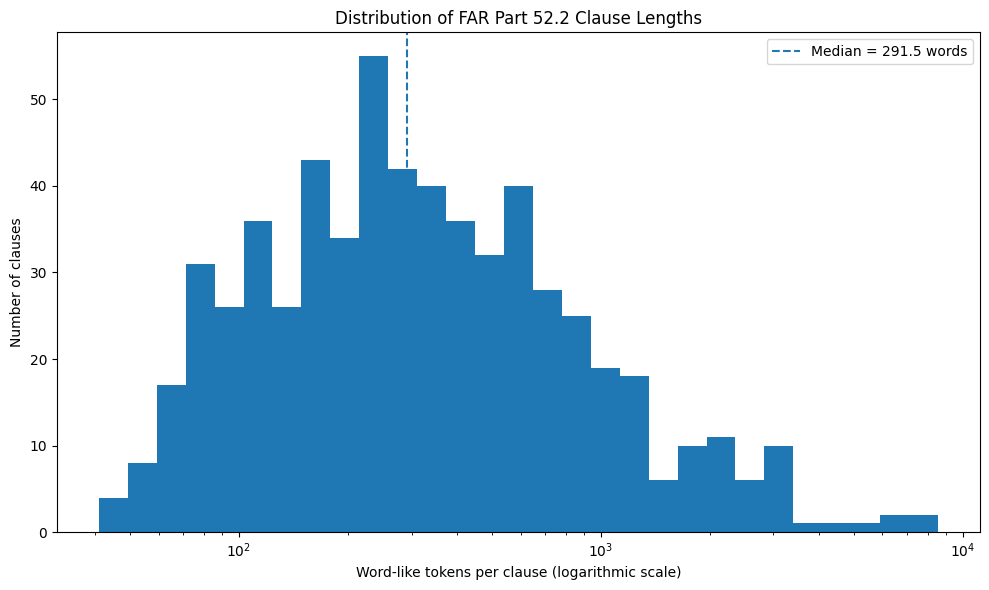

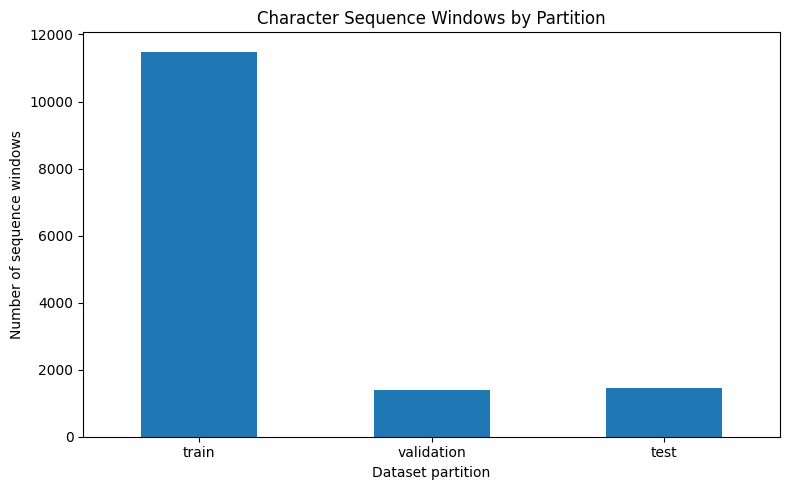

PHASE 3 VISUALIZATION AND ARTIFACT AUDIT: PASS
------------------------------------------------------------------------
Clause-length figure: figures/phase3_clause_length_distribution.png
Sequence-window figure: figures/phase3_sequence_windows_by_split.png
Phase 3 audit: data/audit/PHASE_3_PREPROCESSING_AUDIT.md
Manifest: data/audit/file_manifest.json
All Phase 3 artifact checksums: PASS


In [9]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Output paths
# ------------------------------------------------------------

FIGURES_DIR = REPO_ROOT / "figures"
FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CLAUSE_LENGTH_FIGURE_PATH = (
    FIGURES_DIR
    / "phase3_clause_length_distribution.png"
)

WINDOW_COUNT_FIGURE_PATH = (
    FIGURES_DIR
    / "phase3_sequence_windows_by_split.png"
)

PHASE3_AUDIT_MD_PATH = (
    REPO_ROOT
    / "data"
    / "audit"
    / "PHASE_3_PREPROCESSING_AUDIT.md"
)

MANIFEST_PATH = (
    REPO_ROOT
    / "data"
    / "audit"
    / "file_manifest.json"
)

# ------------------------------------------------------------
# Figure 1: clause-length distribution
# ------------------------------------------------------------

word_counts = (
    split_df["word_count"]
    .astype(int)
)

minimum_words = int(
    word_counts.min()
)

maximum_words = int(
    word_counts.max()
)

median_words = float(
    word_counts.median()
)

log_bins = np.logspace(
    np.log10(minimum_words),
    np.log10(maximum_words),
    num=30,
)

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    word_counts,
    bins=log_bins,
)

plt.xscale("log")

plt.axvline(
    median_words,
    linestyle="--",
    label=(
        f"Median = "
        f"{median_words:,.1f} words"
    ),
)

plt.title(
    "Distribution of FAR Part 52.2 Clause Lengths"
)

plt.xlabel(
    "Word-like tokens per clause "
    "(logarithmic scale)"
)

plt.ylabel(
    "Number of clauses"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    CLAUSE_LENGTH_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()
plt.close()

# ------------------------------------------------------------
# Figure 2: sequence-window counts
# ------------------------------------------------------------

window_counts_for_plot = (
    window_summary.loc[
        SPLIT_ORDER,
        "windows",
    ]
)

plt.figure(
    figsize=(8, 5)
)

window_counts_for_plot.plot(
    kind="bar",
)

plt.title(
    "Character Sequence Windows by Partition"
)

plt.xlabel(
    "Dataset partition"
)

plt.ylabel(
    "Number of sequence windows"
)

plt.xticks(
    rotation=0,
)

plt.tight_layout()

plt.savefig(
    WINDOW_COUNT_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()
plt.close()

# ------------------------------------------------------------
# Create human-readable Phase 3 audit
# ------------------------------------------------------------

validation_unseen_display = json.dumps(
    unseen_characters["validation"],
    ensure_ascii=True,
)

test_unseen_display = json.dumps(
    unseen_characters["test"],
    ensure_ascii=True,
)

missing_families_display = (
    ", ".join(
        families_missing_from_training
    )
    if families_missing_from_training
    else "None"
)

phase3_audit_markdown = f"""# Phase 3 Preprocessing and Sequence Audit

## Clause-Level Split

| Partition | Records | Percentage | Characters | Word-Like Tokens | Families Represented |
|---|---:|---:|---:|---:|---:|
| Train | {int(split_summary.loc["train", "records"]):,} | {float(split_summary.loc["train", "percentage"]):.1f}% | {int(split_summary.loc["train", "characters"]):,} | {int(split_summary.loc["train", "word_like_tokens"]):,} | {int(split_summary.loc["train", "families_represented"]):,} |
| Validation | {int(split_summary.loc["validation", "records"]):,} | {float(split_summary.loc["validation", "percentage"]):.1f}% | {int(split_summary.loc["validation", "characters"]):,} | {int(split_summary.loc["validation", "word_like_tokens"]):,} | {int(split_summary.loc["validation", "families_represented"]):,} |
| Test | {int(split_summary.loc["test", "records"]):,} | {float(split_summary.loc["test", "percentage"]):.1f}% | {int(split_summary.loc["test", "characters"]):,} | {int(split_summary.loc["test", "word_like_tokens"]):,} | {int(split_summary.loc["test", "families_represented"]):,} |

The split was performed at the complete-clause level before sequence-window construction. Record overlap between all partition pairs is zero. The test partition is held out from model selection.

## Character Vocabulary

- Vocabulary source: training partition only
- Training characters: {len(training_characters):,}
- Special tokens: 2 (`<PAD>` and `<UNK>`)
- Total vocabulary size: {VOCAB_SIZE:,}
- Validation-only characters: {validation_unseen_display}
- Test-only characters: {test_unseen_display}
- Families absent from training: {missing_families_display}

Rare validation or test characters not observed in training are mapped to `<UNK>`. Building the vocabulary from training data only prevents information from held-out records from influencing preprocessing.

## Sequence Construction

| Partition | Windows | Records Represented | Padded Windows | Average Valid Tokens | Maximum Windows per Record |
|---|---:|---:|---:|---:|---:|
| Train | {int(window_summary.loc["train", "windows"]):,} | {int(window_summary.loc["train", "records_represented"]):,} | {int(window_summary.loc["train", "padded_windows"]):,} | {float(window_summary.loc["train", "average_valid_tokens"]):.1f} | {int(window_summary.loc["train", "maximum_windows_per_record"]):,} |
| Validation | {int(window_summary.loc["validation", "windows"]):,} | {int(window_summary.loc["validation", "records_represented"]):,} | {int(window_summary.loc["validation", "padded_windows"]):,} | {float(window_summary.loc["validation", "average_valid_tokens"]):.1f} | {int(window_summary.loc["validation", "maximum_windows_per_record"]):,} |
| Test | {int(window_summary.loc["test", "windows"]):,} | {int(window_summary.loc["test", "records_represented"]):,} | {int(window_summary.loc["test", "padded_windows"]):,} | {float(window_summary.loc["test", "average_valid_tokens"]):.1f} | {int(window_summary.loc["test", "maximum_windows_per_record"]):,} |

- Context length: {CONTEXT_LENGTH:,} characters
- Sequence stride: {SEQUENCE_STRIDE:,} characters
- Maximum windows per record: {MAX_WINDOWS_PER_RECORD:,}
- Cross-clause sequence windows: prohibited
- Padding loss policy: padding targets will be ignored by the cross-entropy loss
- Long-clause control: evenly spaced windows are retained across the full clause when the cap is reached

## Phase 3 Conclusion

The corrected FAR corpus has been divided into reproducible, leakage-controlled train, validation, and held-out test partitions. The character vocabulary was derived exclusively from training records. The sequence pipeline retains coverage across every source record while limiting the influence of unusually long clauses. The artifacts are ready for Transformer implementation and smoke testing.
"""

PHASE3_AUDIT_MD_PATH.write_text(
    phase3_audit_markdown,
    encoding="utf-8",
)

# ------------------------------------------------------------
# Update the integrity manifest
# ------------------------------------------------------------

if MANIFEST_PATH.exists():
    manifest = json.loads(
        MANIFEST_PATH.read_text(
            encoding="utf-8"
        )
    )
else:
    manifest = {}

phase3_artifacts = {
    (
        "config/"
        "project_config.json"
    ): CONFIG_PATH,

    (
        "data/audit/"
        "PHASE_3_PREPROCESSING_AUDIT.md"
    ): PHASE3_AUDIT_MD_PATH,

    (
        "data/audit/"
        "phase3_split_audit.json"
    ): (
        REPO_ROOT
        / "data"
        / "audit"
        / "phase3_split_audit.json"
    ),

    (
        "data/audit/"
        "phase3_sequence_audit.json"
    ): (
        REPO_ROOT
        / "data"
        / "audit"
        / "phase3_sequence_audit.json"
    ),

    (
        "data/processed/"
        "far_part_52_2_clauses_with_splits.csv"
    ): (
        REPO_ROOT
        / "data"
        / "processed"
        / "far_part_52_2_clauses_with_splits.csv"
    ),

    (
        "data/processed/"
        "far_part_52_2_split_assignments.csv"
    ): (
        REPO_ROOT
        / "data"
        / "processed"
        / "far_part_52_2_split_assignments.csv"
    ),

    (
        "data/processed/"
        "character_vocabulary.json"
    ): (
        REPO_ROOT
        / "data"
        / "processed"
        / "character_vocabulary.json"
    ),

    (
        "data/processed/"
        "sequence_windows.csv"
    ): (
        REPO_ROOT
        / "data"
        / "processed"
        / "sequence_windows.csv"
    ),

    (
        "figures/"
        "phase3_clause_length_distribution.png"
    ): CLAUSE_LENGTH_FIGURE_PATH,

    (
        "figures/"
        "phase3_sequence_windows_by_split.png"
    ): WINDOW_COUNT_FIGURE_PATH,
}

for relative_path, artifact_path in (
    phase3_artifacts.items()
):
    if not artifact_path.exists():
        raise FileNotFoundError(
            f"Missing Phase 3 artifact: "
            f"{artifact_path}"
        )

    payload = artifact_path.read_bytes()

    manifest[relative_path] = {
        "bytes": len(payload),
        "sha256": hashlib.sha256(
            payload
        ).hexdigest(),
    }

MANIFEST_PATH.write_text(
    json.dumps(
        manifest,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)

# Verify the newly written manifest entries.
for relative_path, artifact_path in (
    phase3_artifacts.items()
):
    calculated_hash = hashlib.sha256(
        artifact_path.read_bytes()
    ).hexdigest()

    recorded_hash = manifest[
        relative_path
    ]["sha256"]

    if calculated_hash != recorded_hash:
        raise AssertionError(
            f"Checksum mismatch: "
            f"{relative_path}"
        )

print(
    "PHASE 3 VISUALIZATION AND "
    "ARTIFACT AUDIT: PASS"
)

print("-" * 72)

print(
    f"Clause-length figure: "
    f"{CLAUSE_LENGTH_FIGURE_PATH.relative_to(REPO_ROOT)}"
)

print(
    f"Sequence-window figure: "
    f"{WINDOW_COUNT_FIGURE_PATH.relative_to(REPO_ROOT)}"
)

print(
    f"Phase 3 audit: "
    f"{PHASE3_AUDIT_MD_PATH.relative_to(REPO_ROOT)}"
)

print(
    f"Manifest: "
    f"{MANIFEST_PATH.relative_to(REPO_ROOT)}"
)

print(
    "All Phase 3 artifact checksums: PASS"
)

## 4. Transformer Architecture and Training

*To be completed in Phases 4-5.*

## 5. Controlled Generation and Output Evaluation

*To be completed in Phase 6.*

## 6. Ethical Considerations and Responsible Use

*To be completed after generated outputs are available so the discussion can be tied directly to observed behavior.*

## 7. Notebook Summary

*The required four-to-six-sentence summary will be written after the final run.*